# Khám Phá Dữ Liệu Sức Khỏe Tâm Thần — Exploring Mental Health Data

## Giới Thiệu Dự Án

Dự án này lấy cảm hứng từ cuộc thi Kaggle **Exploring Mental Health Data**.  
Mục tiêu chính: **dự đoán liệu một người có bị trầm cảm hay không** (`Depression = 1`) dựa trên dữ liệu khảo sát sức khỏe tâm thần.

| Thông tin | Chi tiết |
|---|---|
| **Biến mục tiêu** | `Depression` (0 = không trầm cảm, 1 = trầm cảm) |
| **Tập huấn luyện** | 140 700 mẫu × 20 cột |
| **Đặc trưng** | Nhân khẩu học, áp lực học tập/công việc, thói quen sinh hoạt, tiền sử gia đình |

## Mục Lục

1. Import Thư Viện & Cấu Hình  
2. Tải Dữ Liệu & Khám Phá Ban Đầu  
3. Phân Tích Khám Phá Dữ Liệu (EDA)  
   - 3.1 Phân tích giá trị thiếu
   - 3.2 Phân loại cột số & phân loại
   - 3.3 Phân phối đặc trưng số theo nhãn
   - 3.4 Ma trận tương quan
   - 3.5 Tỷ lệ trầm cảm theo đặc trưng phân loại
   - 3.6 Tiền xử lý dữ liệu & Feature Engineering 
4. Xây Dựng Mô Hình — CatBoost  
5. Đánh Giá Mô Hình CatBoost
6. Tối ưu hóa Threshold (Ngưỡng)
7. Đánh giá ROC-AUC & Biểu đồ phân phối
8. Độ Quan Trọng Đặc Trưng  
9. Mô Hình LightGBM & Random Forest  
10. So Sánh Các Mô Hình  
11. Kiểm Tra Chéo (Cross-Validation)  
12. Kết Luận & Hướng Phát Triển

# Import Thư Viện & Cấu Hình


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score,
                             precision_score, recall_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
%matplotlib inline
sns.set(style="whitegrid")
pd.set_option('display.max_columns', 25)

# Tải Dữ Liệu & Khám Phá Ban Đầu

--- 5 dòng đầu của tập huấn luyện ---


,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0



--- Thông tin chi tiết các cột ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction  

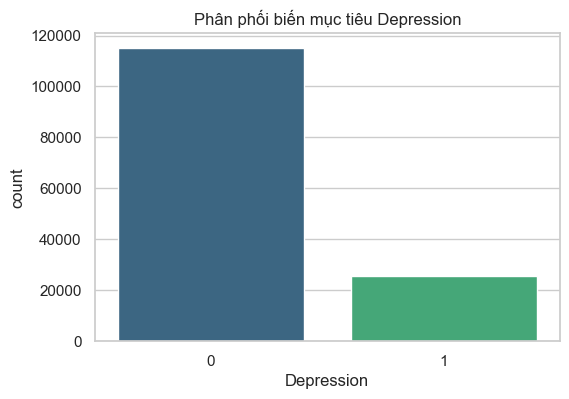

In [2]:
train_df = pd.read_csv('./data/train.csv')
test_df = pd.read_csv('./data/test.csv')

print("--- 5 dòng đầu của tập huấn luyện ---")
display(train_df.head())

print("\n--- Thông tin chi tiết các cột ---")
train_df.info()

plt.figure(figsize=(6, 4))
sns.countplot(x='Depression', data=train_df, palette='viridis')
plt.title('Phân phối biến mục tiêu Depression')
plt.show()

# Phân Tích Khám Phá Dữ Liệu (EDA)


Các cột có giá trị thiếu:
                    Số lượng  Tỷ lệ (%)
Academic Pressure     112803      80.17
Study Satisfaction    112803      80.17
CGPA                  112802      80.17
Profession             36630      26.03
Work Pressure          27918      19.84
Job Satisfaction       27910      19.84
Dietary Habits             4       0.00
Financial Stress           4       0.00
Degree                     2       0.00


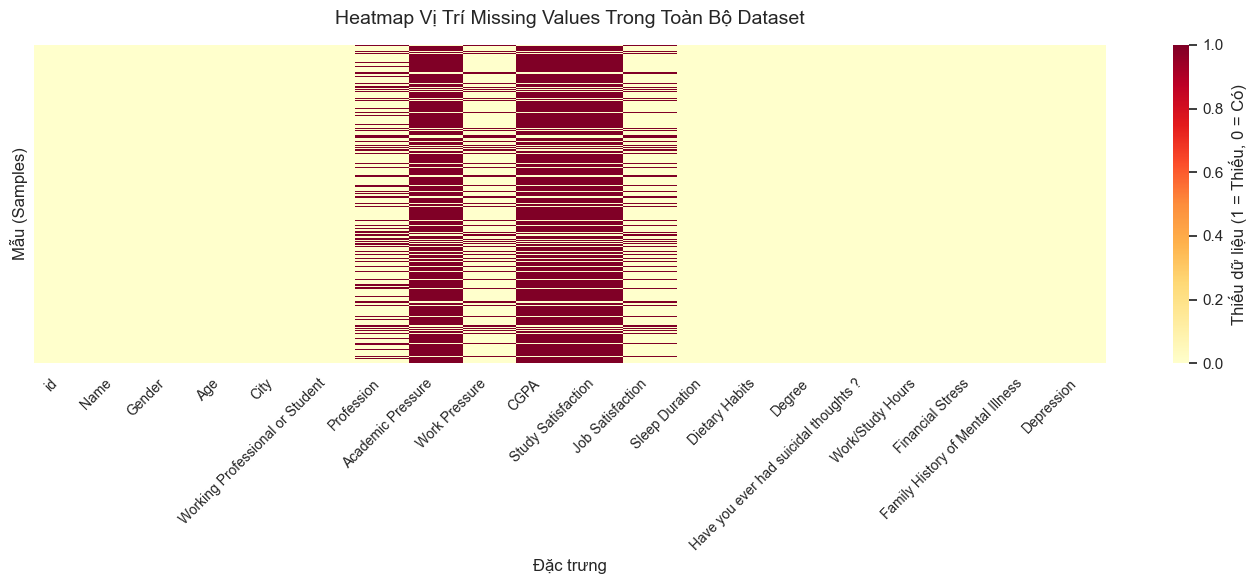

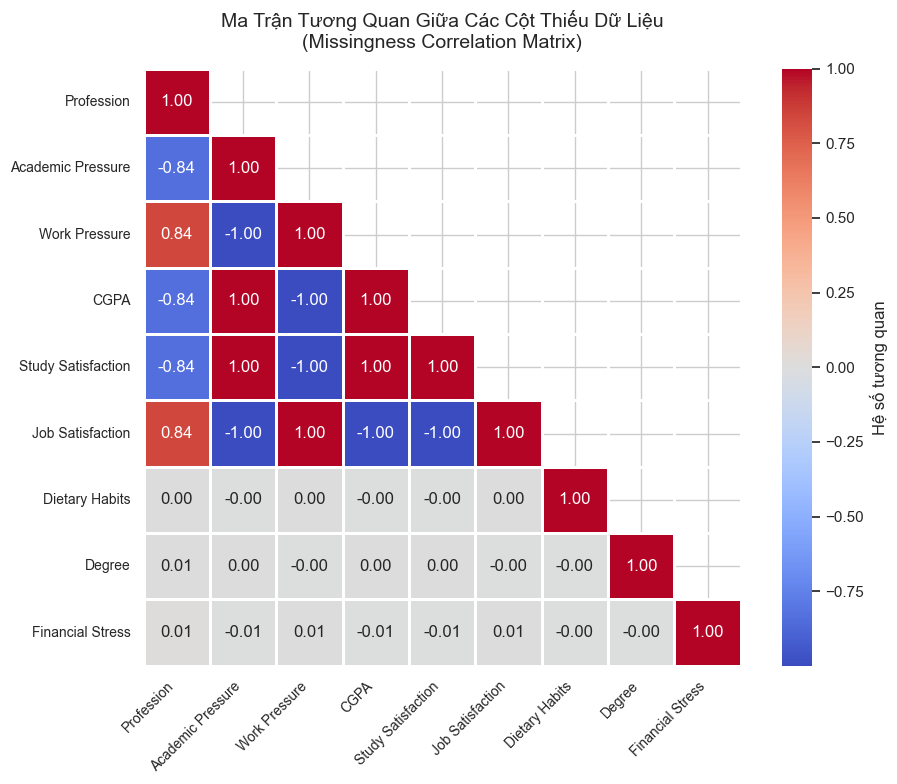


📊 Phân tích Missingness Correlation:
- Hệ số dương cao → hai cột có xu hướng thiếu dữ liệu cùng lúc
- Hệ số âm cao → khi cột này thiếu thì cột kia thường có dữ liệu
- Hệ số gần 0 → việc thiếu dữ liệu giữa hai cột không liên quan


In [3]:
# ==================== MISSING VALUE ====================
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train_df) * 100).round(2)

missing_df = pd.DataFrame({'Số lượng': missing, 'Tỷ lệ (%)': missing_pct})
print("\nCác cột có giá trị thiếu:")
print(missing_df)

# ==================== MISSINGNESS HEATMAP ====================
# Sử dụng heatmap tương quan giữa các cột thiếu dữ liệu
# để phát hiện mẫu (pattern) thiếu dữ liệu có hệ thống
import seaborn as sns

# 1. Heatmap vị trí Missing Values (toàn bộ dataset)
plt.figure(figsize=(14, 6))
sns.heatmap(train_df.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd',
            cbar_kws={'label': 'Thiếu dữ liệu (1 = Thiếu, 0 = Có)'})
plt.title('Heatmap Vị Trí Missing Values Trong Toàn Bộ Dataset', fontsize=14, pad=15)
plt.xlabel('Đặc trưng', fontsize=12)
plt.ylabel('Mẫu (Samples)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

# 2. Ma trận tương quan giữa các cột thiếu dữ liệu (Missingness Correlation)
# Giúp phát hiện: nếu cột A thiếu thì cột B có thiếu theo không?
missing_cols = train_df.columns[train_df.isnull().any()].tolist()

if len(missing_cols) > 1:
    missing_indicator = train_df[missing_cols].isnull().astype(int)
    miss_corr = missing_indicator.corr()
    
    plt.figure(figsize=(10, 8))
    mask = np.triu(np.ones_like(miss_corr, dtype=bool), k=1)
    sns.heatmap(miss_corr, mask=mask, annot=True, fmt='.2f',
                cmap='coolwarm', center=0,
                square=True, linewidths=1,
                cbar_kws={'label': 'Hệ số tương quan'})
    plt.title('Ma Trận Tương Quan Giữa Các Cột Thiếu Dữ Liệu\n(Missingness Correlation Matrix)',
              fontsize=14, pad=15)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()
    
    print('\n📊 Phân tích Missingness Correlation:')
    print('- Hệ số dương cao → hai cột có xu hướng thiếu dữ liệu cùng lúc')
    print('- Hệ số âm cao → khi cột này thiếu thì cột kia thường có dữ liệu')
    print('- Hệ số gần 0 → việc thiếu dữ liệu giữa hai cột không liên quan')
else:
    print('\nChỉ có một cột thiếu dữ liệu, không cần ma trận tương quan.')


### 1. Nhóm tương quan cao (~±0.84 đến ±1.00)
- `Academic Pressure`, `CGPA`, `Study Satisfaction` tương quan **âm mạnh** với `Profession` và `Work Pressure`, `Job Satisfaction`
- Điều này xác nhận: **khi một dòng là Student** → có `Academic Pressure`, `CGPA`, `Study Satisfaction` nhưng **thiếu** `Work Pressure`, `Job Satisfaction`, `Profession`
- Ngược lại với **Working Professional**
- → Missing hoàn toàn **có chủ đích**, phân tách rõ ràng theo nhóm `Student` vs `Working Professional`

### 2. Nhóm tương quan gần 0
- `Dietary Habits`, `Degree`, `Financial Stress` có tương quan gần **0.00** với tất cả các cột còn lại
- → Missing ở các cột này là **ngẫu nhiên (MCAR)**, không liên quan đến role hay bất kỳ cột nào khác
- → Việc **drop thẳng** các dòng này là hợp lý vì số lượng rất ít

In [4]:
role_counts = train_df['Working Professional or Student'].value_counts()
print("=== Số lượng Working Professional vs Student ===")
print(role_counts)

print("\n=== Kiểm tra Missing theo từng cột ===")
check_cols = {
    'Academic Pressure'  : 'Student',
    'CGPA'               : 'Student',
    'Study Satisfaction' : 'Student',
    'Work Pressure'      : 'Working Professional',
    'Job Satisfaction'   : 'Working Professional',
    'Profession'         : 'Working Professional',  # Student không có nghề nghiệp
}

for col, expected_group in check_cols.items():
    missing_count = train_df[col].isnull().sum()
    other_group = 'Working Professional' if expected_group == 'Student' else 'Student'
    other_count = role_counts.get(other_group, 0)
    diff = abs(missing_count - other_count)
    match = "✅" if diff < 100 else "❌"
    print(f"{match} {col:25s} | missing: {missing_count:6d} | {other_group}: {other_count:6d} | diff: {diff}")

=== Số lượng Working Professional vs Student ===
Working Professional or Student
Working Professional    112799
Student                  27901
Name: count, dtype: int64

=== Kiểm tra Missing theo từng cột ===
✅ Academic Pressure         | missing: 112803 | Working Professional: 112799 | diff: 4
✅ CGPA                      | missing: 112802 | Working Professional: 112799 | diff: 3
✅ Study Satisfaction        | missing: 112803 | Working Professional: 112799 | diff: 4
✅ Work Pressure             | missing:  27918 | Student:  27901 | diff: 17
✅ Job Satisfaction          | missing:  27910 | Student:  27901 | diff: 9
❌ Profession                | missing:  36630 | Student:  27901 | diff: 8729


In [5]:
# Số lượng mỗi loại cột
num_cols = train_df.select_dtypes(include=['float64','int64']).columns.tolist()
cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()
print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['id', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Depression']
Categorical columns: ['Name', 'Gender', 'City', 'Working Professional or Student', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


In [6]:
for column in cat_cols:
    num_unique = train_df[column].nunique()
    print(f"'{column}' has {num_unique} unique categories.")

'Name' has 422 unique categories.
'Gender' has 2 unique categories.
'City' has 98 unique categories.
'Working Professional or Student' has 2 unique categories.
'Profession' has 64 unique categories.
'Sleep Duration' has 36 unique categories.
'Dietary Habits' has 23 unique categories.
'Degree' has 115 unique categories.
'Have you ever had suicidal thoughts ?' has 2 unique categories.
'Family History of Mental Illness' has 2 unique categories.



3.3  PHÂN PHỐI ĐẶC TRƯNG SỐ THEO NHÃN (Violin + Box Plot)


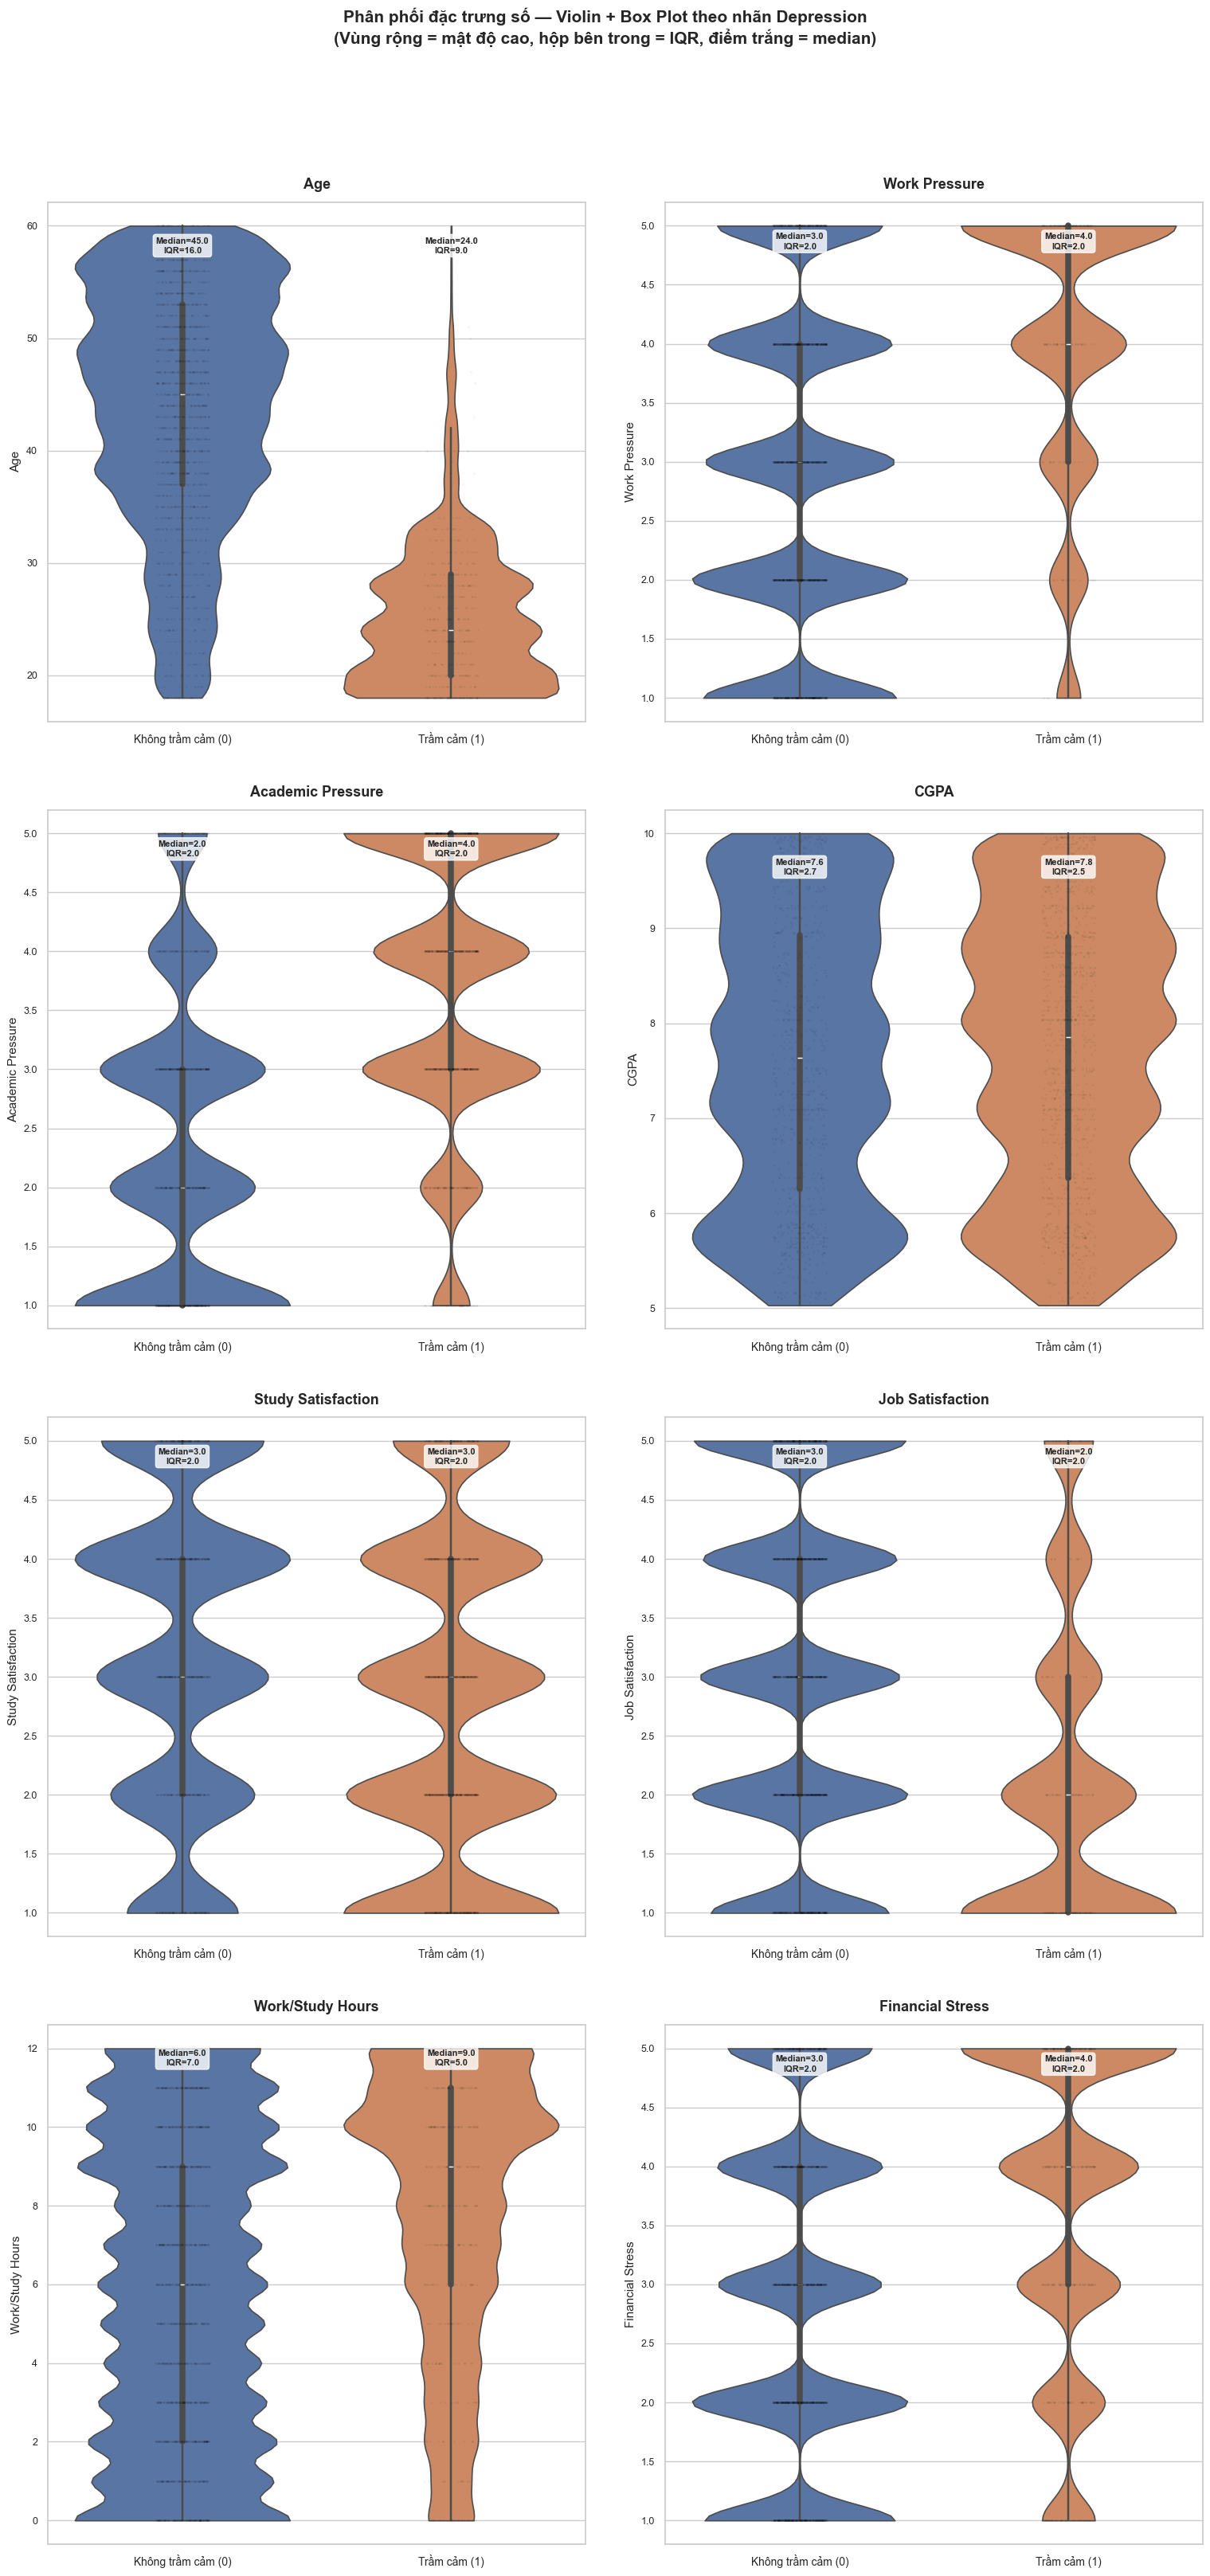

In [7]:
# --- 3.3 Phân phối các đặc trưng số theo nhãn Depression ---
# Sử dụng Violin Plot kết hợp Box Plot để:
# - Xem phân phối dữ liệu chi tiết hơn Histogram
# - Xác định rõ outliers và IQR (khoảng biến thiên)
# - So sánh trực tiếp giữa hai nhóm Trầm cảm / Không trầm cảm

print('\n' + '=' * 60)
print('3.3  PHÂN PHỐI ĐẶC TRƯNG SỐ THEO NHÃN (Violin + Box Plot)')
print('=' * 60)

num_cols = ['Age', 'Work Pressure', 'Academic Pressure', 'CGPA',
            'Study Satisfaction', 'Job Satisfaction',
            'Work/Study Hours', 'Financial Stress']

# Tạo cột nhãn đẹp hơn cho biểu đồ
plot_df = train_df.copy()
plot_df['Depression_Label'] = plot_df['Depression'].map(
    {0: 'Không trầm cảm (0)', 1: 'Trầm cảm (1)'})

fig, axes = plt.subplots(4, 2, figsize=(16, 32))
axes = axes.flatten()

palette = {'Không trầm cảm (0)': '#4C72B0', 'Trầm cảm (1)': '#DD8452'}

for i, col in enumerate(num_cols):
    # Violin plot với inner box plot
    sns.violinplot(data=plot_df, x='Depression_Label', y=col,
                   ax=axes[i], palette=palette,
                   inner='box', cut=0, linewidth=1.2)
    
    # Thêm strip plot (các điểm dữ liệu mẫu)
    sample_df = plot_df[[col, 'Depression_Label']].dropna()
    if len(sample_df) > 2000:
        sample_df = sample_df.sample(2000, random_state=42)
    sns.stripplot(data=sample_df, x='Depression_Label', y=col,
                  ax=axes[i], color='black', alpha=0.05, size=2, jitter=True)
    
    axes[i].set_title(col, fontsize=13, fontweight='bold', pad=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col, fontsize=11)
    axes[i].tick_params(axis='x', labelsize=10)
    axes[i].tick_params(axis='y', labelsize=9)
    
    # Thêm thông tin thống kê (median, IQR) cho mỗi nhóm
    for j, label in enumerate(['Không trầm cảm (0)', 'Trầm cảm (1)']):
        subset = plot_df.loc[plot_df['Depression_Label'] == label, col].dropna()
        if len(subset) > 0:
            median_val = subset.median()
            q1 = subset.quantile(0.25)
            q3 = subset.quantile(0.75)
            iqr = q3 - q1
            axes[i].text(j, axes[i].get_ylim()[1] * 0.95,
                        f'Median={median_val:.1f}\nIQR={iqr:.1f}',
                        ha='center', va='top', fontsize=8,
                        fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.3',
                                  facecolor='white', alpha=0.8))

plt.suptitle('Phân phối đặc trưng số — Violin + Box Plot theo nhãn Depression\n'
             '(Vùng rộng = mật độ cao, hộp bên trong = IQR, điểm trắng = median)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(pad=3.0)
plt.show()



3.4  MA TRẬN TƯƠNG QUAN


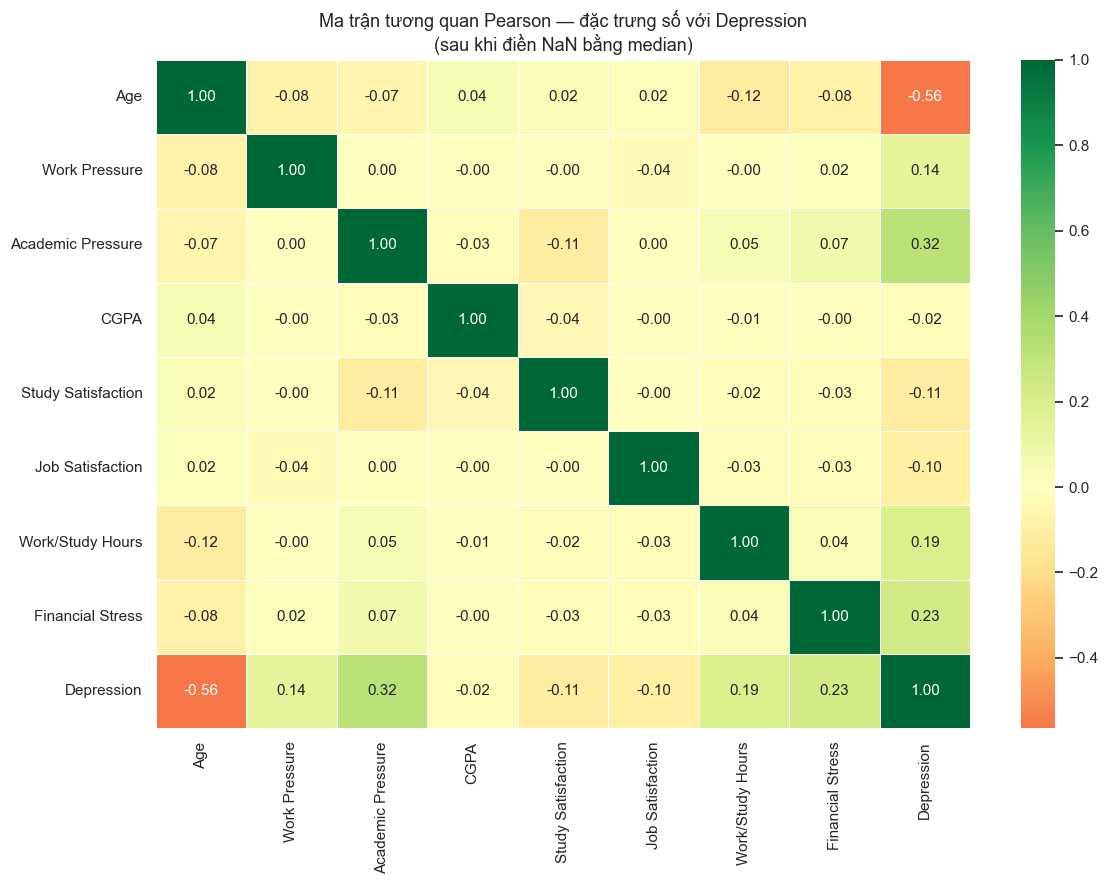


Mức độ tương quan (|r|) với Depression:
  - Age                       |r| = 0.565
  + Academic Pressure         |r| = 0.317
  + Financial Stress          |r| = 0.227
  + Work/Study Hours          |r| = 0.192
  + Work Pressure             |r| = 0.138
  - Study Satisfaction        |r| = 0.114
  - Job Satisfaction          |r| = 0.103
  - CGPA                      |r| = 0.023

→ Age tương quan âm mạnh: người trẻ có tỷ lệ trầm cảm cao hơn.
→ Academic Pressure tương quan dương: áp lực học cao → dễ trầm cảm hơn.


In [ ]:
# --- 3.4 Ma trận tương quan (Correlation Matrix) ---
print("=" * 60)
print("3.4  MA TRẬN TƯƠNG QUAN")
print("=" * 60)

corr_cols = ['Age', 'Work Pressure', 'Academic Pressure', 'CGPA',
             'Study Satisfaction', 'Job Satisfaction',
             'Work/Study Hours', 'Financial Stress', 'Depression']

# Tạo bản sao tạm, điền NaN bằng median để tính tương quan đúng
corr_temp = train_df[corr_cols].copy()
for col in corr_cols:
    corr_temp[col] = pd.to_numeric(corr_temp[col], errors='coerce')
    corr_temp[col] = corr_temp[col].fillna(corr_temp[col].median())

corr_matrix = corr_temp.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5,
            annot_kws={'size': 11})
plt.title('Ma trận tương quan Pearson — đặc trưng số với Depression\n'
          '(sau khi điền NaN bằng median)', fontsize=13)
plt.tight_layout()
plt.show()

# In tương quan với Depression (sắp xếp giảm dần theo |r|)
print("\nMức độ tương quan (|r|) với Depression:")
top_corr = (corr_matrix['Depression']
            .abs()
            .sort_values(ascending=False)
            .drop('Depression'))
for feat, val in top_corr.items():
    sign = '+' if corr_matrix['Depression'][feat] > 0 else '-'
    print(f"  {sign} {feat:<25} |r| = {val:.3f}")

## Nhận xét Ma Trận Tương Quan Pearson — Đặc trưng số với Depression

### 1. Các yếu tố tương quan mạnh nhất với Depression

| Cột | Tương quan | Chiều |
|-----|-----------|-------|
| `Age` | **-0.56** | Tuổi càng cao → ít trầm cảm hơn |
| `Academic Pressure` | **+0.32** | Áp lực học tập càng cao → dễ trầm cảm |
| `Financial Stress` | **+0.23** | Căng thẳng tài chính càng cao → dễ trầm cảm |
| `Work/Study Hours` | **+0.19** | Làm/học nhiều giờ → dễ trầm cảm |
| `Work Pressure` | **+0.14** | Áp lực công việc → ít ảnh hưởng hơn Academic |

### 2. Các yếu tố tương quan yếu với Depression
- `Study Satisfaction` (-0.11) và `Job Satisfaction` (-0.10): tương quan âm nhẹ
  → Hài lòng cao thì ít trầm cảm hơn, nhưng mức độ ảnh hưởng không lớn
- `CGPA` (-0.02): **gần như không tương quan** với Depression

### 3. Đa cộng tuyến giữa các đặc trưng
- Hầu hết các cặp đặc trưng có tương quan **gần 0** với nhau
- → Ít rủi ro multicollinearity, các đặc trưng mang thông tin **độc lập**

### 4. Kết luận
- `Age` là đặc trưng **quan trọng nhất**, tương quan âm mạnh với Depression
- Nhóm **Student** (Academic Pressure cao, tuổi trẻ) có nguy cơ trầm cảm cao hơn
- `CGPA` gần như không có giá trị dự đoán → có thể cân nhắc loại bỏ


3.5  TỶ LỆ TRẦM CẢM THEO ĐẶC TRƯNG PHÂN LOẠI (Normalized Stacked Bar)


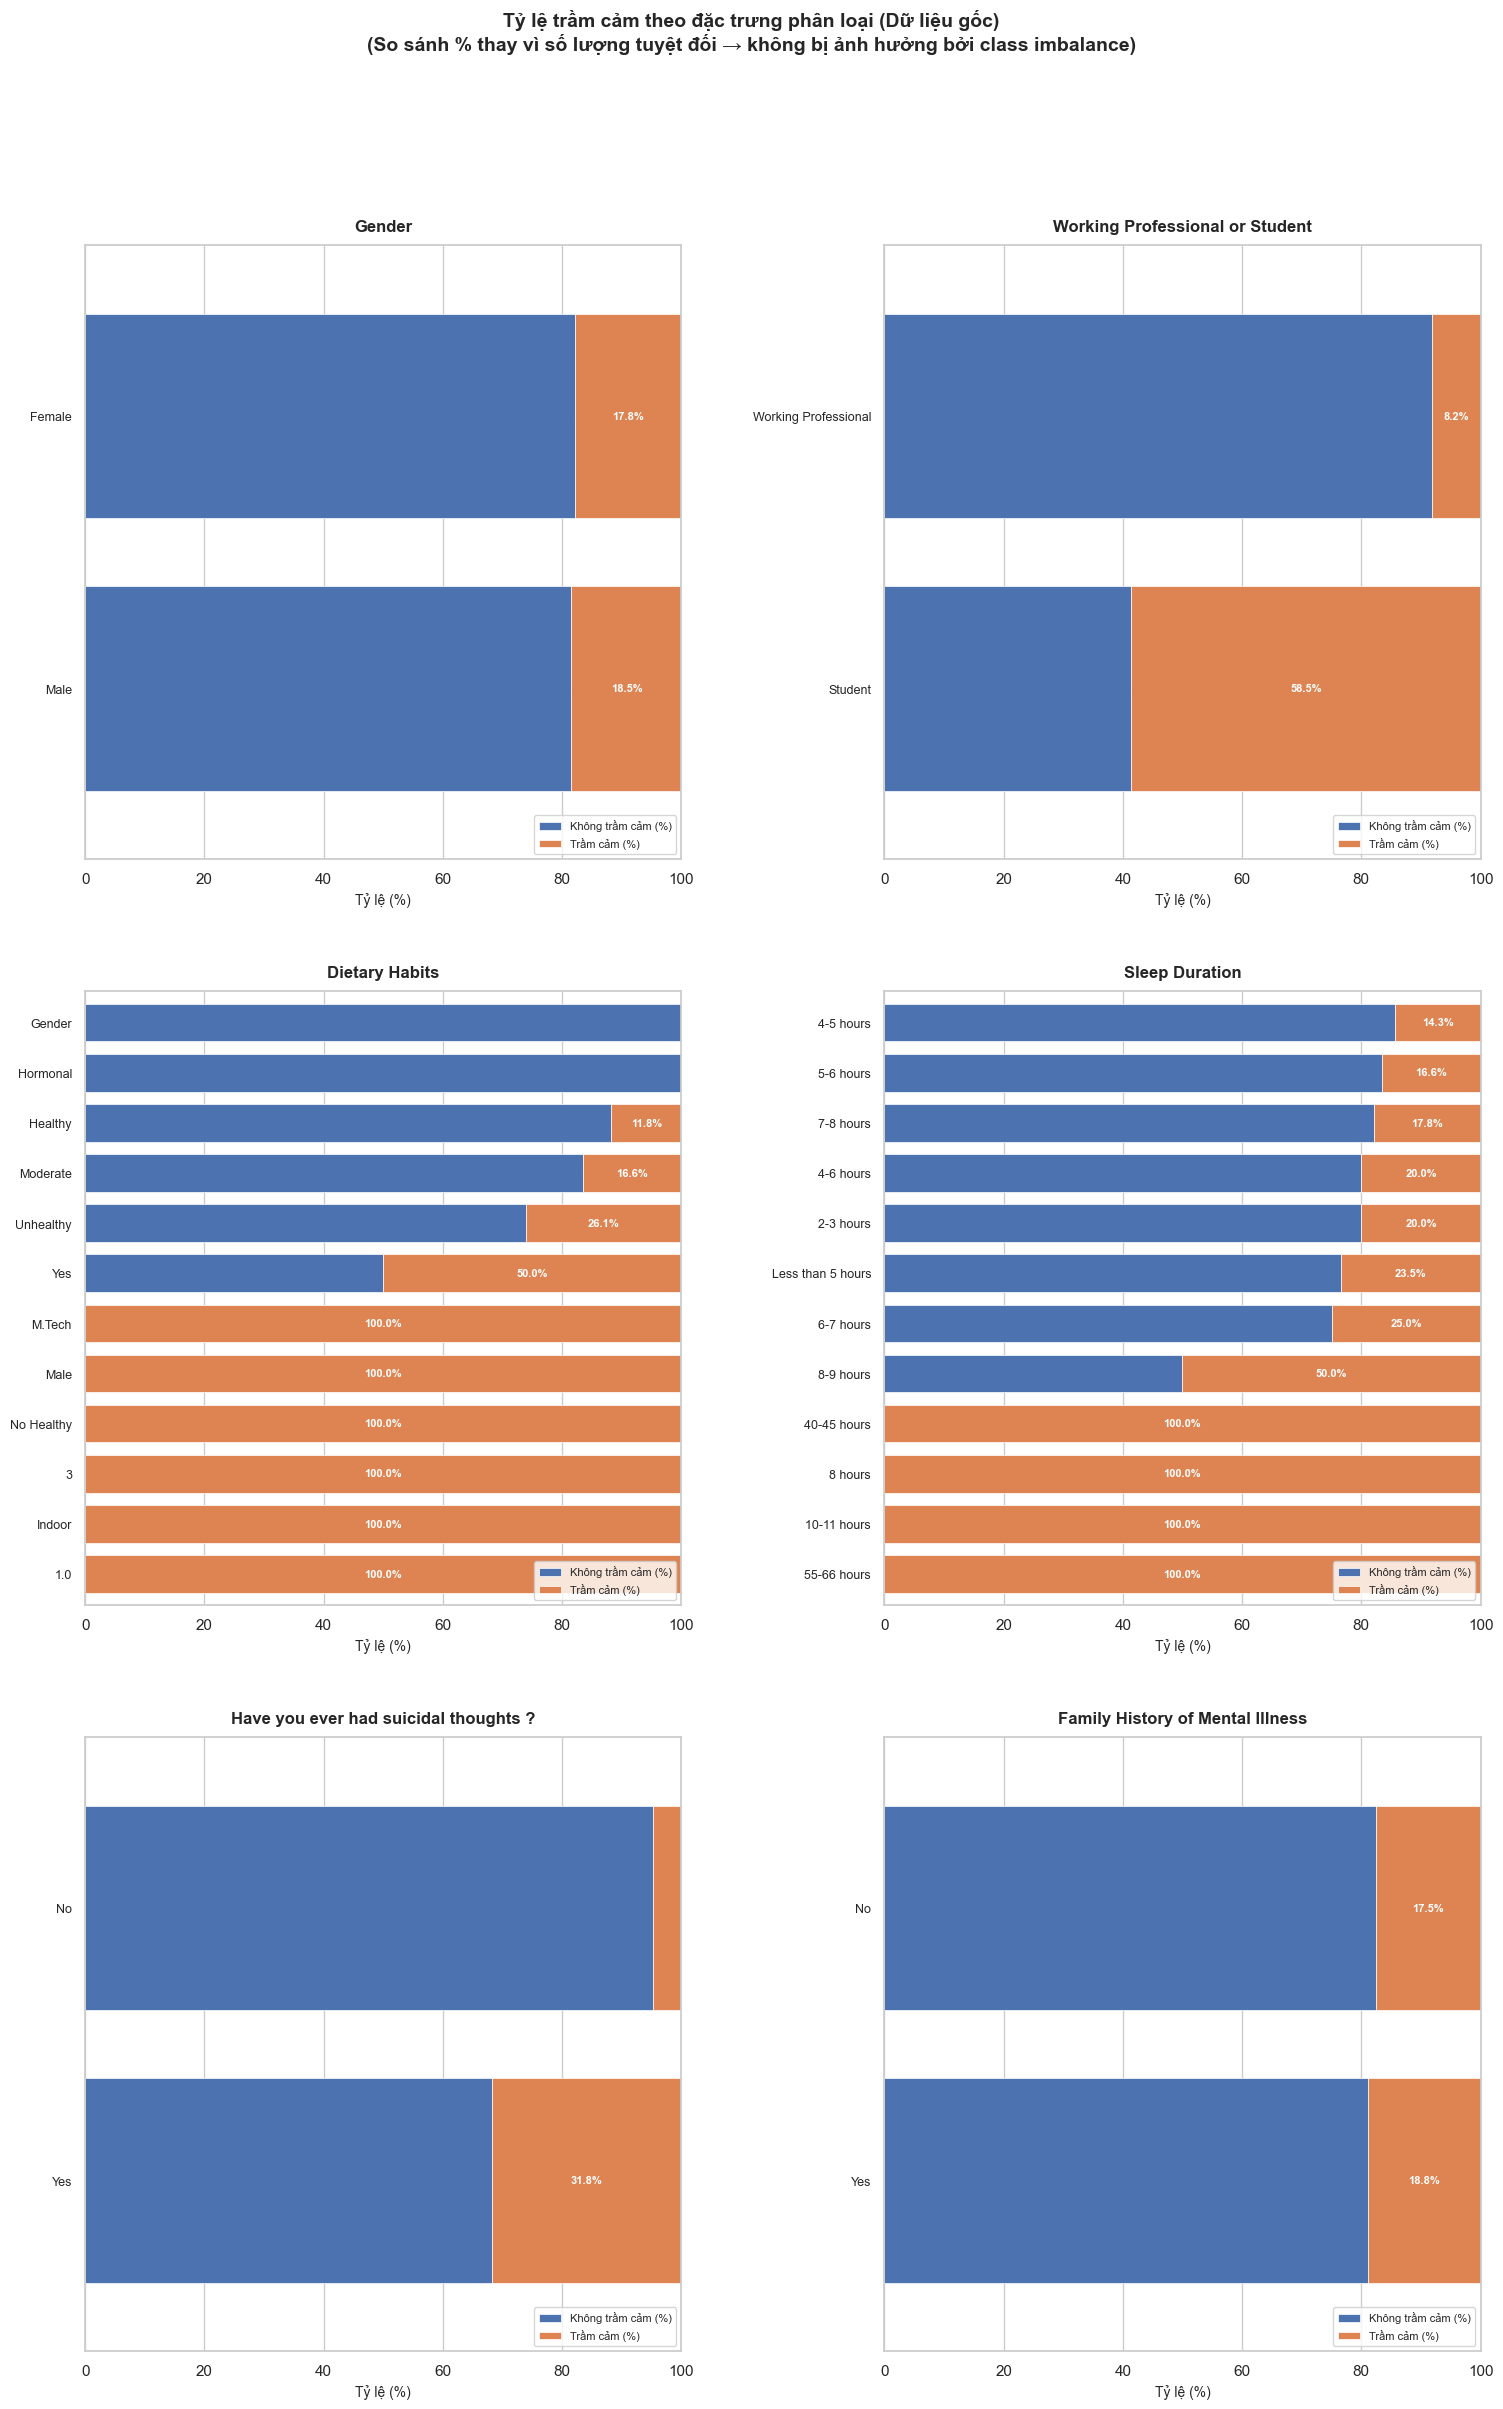

In [ ]:
# --- 3.5 Tỷ lệ trầm cảm theo đặc trưng phân loại quan trọng ---
# Sử dụng Normalized Stacked Bar (biểu đồ cột chồng chuẩn hóa %)
# để so sánh chính xác tỷ lệ trầm cảm giữa các nhóm,
# không bị ảnh hưởng bởi sự CHÊNH LỆCH SỐ LƯỢNG mẫu.

print('\n' + '=' * 60)
print('3.5  TỶ LỆ TRẦM CẢM THEO ĐẶC TRƯNG PHÂN LOẠI (Normalized Stacked Bar)')
print('=' * 60)

cat_important = [
    'Gender', 'Working Professional or Student',
    'Dietary Habits', 'Sleep Duration',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness'
]

fig, axes = plt.subplots(3, 2, figsize=(16, 24))
axes = axes.flatten()

colors_stack = ['#4C72B0', '#DD8452']

for i, col in enumerate(cat_important):
    # Tạo bảng chéo (crosstab) và chuẩn hóa theo phần trăm
    ct = pd.crosstab(train_df[col], train_df['Depression'],
                     normalize='index') * 100
    ct.columns = ['Không trầm cảm (%)', 'Trầm cảm (%)']
    
    # Sắp xếp theo tỷ lệ trầm cảm giảm dần, lấy top 12
    ct = ct.sort_values('Trầm cảm (%)', ascending=False).head(12)
    
    # Vẽ biểu đồ cột chồng chuẩn hóa
    ct.plot(kind='barh', stacked=True, ax=axes[i],
            color=colors_stack, edgecolor='white', linewidth=0.5,
            width=0.75)
    
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel('Tỷ lệ (%)', fontsize=10)
    axes[i].set_ylabel('')
    axes[i].set_xlim(0, 100)
    axes[i].tick_params(axis='y', labelsize=9)
    axes[i].legend(fontsize=8, loc='lower right')
    
    # Thêm nhãn % trên mỗi thanh
    for bar_idx, (idx_name, row) in enumerate(ct.iterrows()):
        dep_pct = row['Trầm cảm (%)']
        non_dep_pct = row['Không trầm cảm (%)']
        if dep_pct > 5:
            axes[i].text(non_dep_pct + dep_pct / 2, bar_idx,
                        f'{dep_pct:.1f}%',
                        ha='center', va='center', fontsize=8,
                        fontweight='bold', color='white')

plt.suptitle('Tỷ lệ trầm cảm theo đặc trưng phân loại (Dữ liệu gốc)\n'
             '(So sánh % thay vì số lượng tuyệt đối → không bị ảnh hưởng bởi class imbalance)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(pad=3.5)
plt.show()


## Nhận xét Tỷ lệ Trầm cảm theo Đặc trưng Phân loại

### 1. Gender (Giới tính)
- Tỷ lệ trầm cảm giữa Nam (18.5%) và Nữ (17.8%) **gần như không có sự khác biệt**
- → `Gender` có thể không phải yếu tố dự đoán mạnh

### 2. Working Professional or Student
- **Student có tỷ lệ trầm cảm vượt trội: 36.5%** so với Working Professional chỉ 6.2%
- → Đây là một trong những đặc trưng **phân biệt mạnh nhất**, nhất quán với
  kết quả tương quan Pearson (`Age` âm mạnh, `Academic Pressure` dương mạnh)

### 3. Dietary Habits
- Chế độ ăn càng kém lành mạnh → tỷ lệ trầm cảm càng cao:
  - Healthy: **11.8%** → Moderate: **18.6%** → Unhealthy: **26.1%**
- Các giá trị nhiễu (`M.Tech`, `Male`, `No Healthy`, `Indoor`...) đều có tỷ lệ
  100% trầm cảm → xác nhận đây là **noise**, cần làm sạch trước khi train
- → `Dietary Habits` là đặc trưng **có giá trị dự đoán tốt**

### 4. Sleep Duration
- Các giá trị hợp lệ: ngủ ít hơn có xu hướng trầm cảm cao hơn, tuy nhiên
  mức chênh lệch không quá lớn (14.3% → 30.9%)
- Các giá trị bất thường (`40-45 hours`, `55-66 hours`, `10-11 hours`) đều
  100% trầm cảm → **noise cần loại bỏ**, xác nhận quyết định clip outlier trong `parse_sleep`

### 5. Have you ever had suicidal thoughts?
- Có suy nghĩ tự tử → tỷ lệ trầm cảm **31.6%**, không có → gần 0%
- → Đặc trưng **phân biệt rất mạnh** với Depression

### 6. Family History of Mental Illness
- Có tiền sử gia đình (18.9%) vs không có (17.9%) → **chênh lệch rất nhỏ**
- → Đặc trưng này ít có giá trị dự đoán hơn kỳ vọng

### Tổng kết
Các đặc trưng phân loại quan trọng nhất theo thứ tự:
1. `Working Professional or Student` — chênh lệch lớn nhất (6.2% vs 36.5%)
2. `Have you ever had suicidal thoughts?` — phân biệt rõ ràng
3. `Dietary Habits` — xu hướng đơn điệu rõ ràng
4. `Sleep Duration` — có xu hướng nhưng cần làm sạch noise
5. `Gender`, `Family History` — ít có giá trị phân biệt

In [24]:
# --- 3.6 Tiền xử lí & làm sạch dữ liệu ---
print("=" * 60)
print("3.6 Tiền xử lí & làm sạch dữ liệu")
print("=" * 60)

import re
def parse_sleep(val):
    val = str(val).strip().lower()
    
    if 'less than 5' in val or val == 'than 5 hours':
        return 4.0
    if 'more than 8' in val:
        return 9.0
    
    numbers = re.findall(r'\d+\.?\d*', val)
    
    if len(numbers) == 2:
        a, b = float(numbers[0]), float(numbers[1])
        avg = (a + b) / 2
        if avg > 14 or avg < 1:
            return np.nan
        return avg
    elif len(numbers) == 1:
        val_num = float(numbers[0])
        if val_num > 14 or val_num < 1:
            return np.nan
        return val_num
    
    return np.nan

def preprocess_data(df,is_train=True):
    data = df.copy()
    
    # ============================================================
    # 1. Xử lý Missing Values
    # ============================================================

    # Nhóm 1: Missing có chủ đích → fillna 0
    zero_fill_cols = ['Academic Pressure', 'Study Satisfaction', 'CGPA',
                      'Work Pressure', 'Job Satisfaction']
    for col in zero_fill_cols:
        data[col] = pd.to_numeric(data[col], errors='coerce')
        data[col] = data[col].fillna(0)

    # Nhóm 2: Fillna theo role
    is_student = data['Working Professional or Student'] == 'Student'
    is_wp      = data['Working Professional or Student'] == 'Working Professional'

    # Profession
    data.loc[is_student & data['Profession'].isnull(), 'Profession'] = 'Student'
    data.loc[is_wp      & data['Profession'].isnull(), 'Profession'] = 'Unknown'

    # Nhóm 3: ~0% missing → drop luôn
    if is_train:
        data = data.dropna(subset=['Dietary Habits', 'Financial Stress', 'Degree'])
    else:
        data['Dietary Habits']  = data['Dietary Habits'].fillna('Missing')
        data['Financial Stress'] = data['Financial Stress'].fillna(data['Financial Stress'].median())
        data['Degree']          = data['Degree'].fillna('Missing')


    # ============================================================
    # 2. Làm sạch Sleep Duration
    # ============================================================
    data['Sleep Duration'] = data['Sleep Duration'].apply(parse_sleep)
    median_sleep = data['Sleep Duration'].median()
    data['Sleep Duration'] = data['Sleep Duration'].fillna(median_sleep)


    # ============================================================
    # 3. Làm sạch Dietary Habits
    # ============================================================
    valid_habits = ['Healthy', 'Moderate', 'Unhealthy']
    data.loc[~data['Dietary Habits'].isin(valid_habits), 'Dietary Habits'] = 'Missing'

    # ============================================================
    # 4. Xử lý Work/Study Hours
    # ============================================================
    data['Work/Study Hours'] = pd.to_numeric(data['Work/Study Hours'], errors='coerce')
    data['Work/Study Hours'] = data['Work/Study Hours'].fillna(
        data['Work/Study Hours'].median())
    

    # ============================================================
    # 5. Financial Stress
    # ============================================================
    data['Financial Stress'] = pd.to_numeric(data['Financial Stress'], errors='coerce')

    # ============================================================
    # 6. Feature Engineering
    # ============================================================
    # (a) Tỷ lệ giờ làm/học so với giờ ngủ → chỉ số áp lực thời gian
    #     Công thức: Work_Sleep_Ratio = Work_Hours / (Sleep_Hours + 1)
    data['Work_Sleep_Ratio'] = data['Work/Study Hours'] / (data['Sleep Duration'] + 1)

    # (b) Tổng áp lực: kết hợp áp lực học tập và áp lực công việc
    data['Total_Pressure'] = data['Academic Pressure'] + data['Work Pressure']

    # (c) Tổng hài lòng: kết hợp sự hài lòng về học tập và công việc
    data['Total_Satisfaction'] = data['Study Satisfaction'] + data['Job Satisfaction']

    return data


# --- Áp dụng tiền xử lý ---
train_processed = preprocess_data(train_df, is_train=True)
test_processed  = preprocess_data(test_df,  is_train=False)

print(f"\nTiền xử lý hoàn tất!")
print(f"  Số cột sau feature engineering: {train_processed.shape[1]}")

3.6 Tiền xử lí & làm sạch dữ liệu

Tiền xử lý hoàn tất!
  Số cột sau feature engineering: 23


In [25]:
train_processed = preprocess_data(train_df)

missing_after = train_processed.isnull().sum()
missing_after = missing_after[missing_after > 0]

if missing_after.empty:
    print("✅ Không còn missing values!")
else:
    print("❌ Vẫn còn missing values:")
    print(missing_after)

# print(train_processed.head())

✅ Không còn missing values!


# Xây Dựng Mô Hình — CatBoost

In [12]:
# Chuẩn bị dữ liệu cho mô hình
X = train_processed.drop(['id', 'Name', 'Depression','Academic Pressure',  'Work Pressure', 'Study Satisfaction', 'Job Satisfaction'], axis=1)
print(X.columns.tolist())
y = train_processed['Depression']
X_test = test_processed.drop(['id', 'Name','Academic Pressure',  'Work Pressure', 'Study Satisfaction', 'Job Satisfaction'], axis=1)
print(X_test.columns.tolist())

# Xác định danh sách các cột phân loại cho CatBoost
cat_features = list(X.select_dtypes(include=['object']).columns)


# Chia tập dữ liệu để kiểm tra (Validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Khởi tạo mô hình CatBoost
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    cat_features=cat_features,
    verbose=100, # In kết quả mỗi 100 vòng lặp [Yêu cầu đồ án]
    random_seed=42
)

# Huấn luyện mô hình
model.fit(X_train, y_train, eval_set=(X_val, y_val))

['Gender', 'Age', 'City', 'Working Professional or Student', 'Profession', 'CGPA', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Work_Sleep_Ratio', 'Total_Pressure', 'Total_Satisfaction']
['Gender', 'Age', 'City', 'Working Professional or Student', 'Profession', 'CGPA', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Work_Sleep_Ratio', 'Total_Pressure', 'Total_Satisfaction']
0:	learn: 0.6076846	test: 0.6075091	best: 0.6075091 (0)	total: 194ms	remaining: 3m 14s
100:	learn: 0.1512513	test: 0.1509719	best: 0.1509719 (100)	total: 5.01s	remaining: 44.6s
200:	learn: 0.1471056	test: 0.1484574	best: 0.1484574 (200)	total: 9.48s	remaining: 37.7s
300:	learn: 0.1450318	test: 0.1479668	best: 0.1479662 (298)	total: 14s	remaining: 32.6s
400:	learn: 0.1434572	test: 0.147

CatBoostClassifier(cat_features=['Gender', 'City', 'Working Professional or Student', 'Profession', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness'], depth=6, iterations=1000, learning_rate=0.05, random_seed=42, verbose=100)

# Đánh Giá Mô Hình CatBoost

In [33]:
# Dự đoán trên tập validation
y_pred = model.predict(X_val)
acc = accuracy_score(y_val, y_pred)

print(f"\nĐộ chính xác (Accuracy) trên tập Validation: {acc:.4f}")
print("\n--- Báo cáo chi tiết ---")
print(classification_report(y_val, y_pred))

# Dự đoán trên tập Test để nộp bài
test_preds = model.predict(X_test)

# Tạo file submission
submission = pd.DataFrame({
    'id': test_df['id'],
    'Depression': test_preds
})
# submission.to_csv('submission.csv', index=False)
# print("\nĐã lưu file submission.csv thành công!")


Độ chính xác (Accuracy) trên tập Validation: 0.9411

--- Báo cáo chi tiết ---
              precision    recall  f1-score   support

           0       0.96      0.97      0.96     23025
           1       0.85      0.82      0.83      5113

    accuracy                           0.94     28138
   macro avg       0.91      0.89      0.90     28138
weighted avg       0.94      0.94      0.94     28138



### Nhận xét
- Model dự đoán **lớp 0 rất tốt** (F1 = 0.96) do số lượng mẫu áp đảo
  (23025 vs 5113 — tỷ lệ ~4.5:1)
- **Lớp 1 yếu hơn** (F1 = 0.83): Recall = 0.82 có nghĩa là cứ 100 người
  thực sự trầm cảm thì model **bỏ sót 18 người**
- Đây là dấu hiệu của **class imbalance** — model thiên về dự đoán lớp 0

# Tối ưu hóa Threshold (Ngưỡng)

[9.41687875e-01 1.35074898e-04 6.81736246e-01 ... 7.75316639e-04
 8.67176128e-04 4.09951717e-03]
Threshold tốt nhất: 0.44
F1-Score cao nhất trên tập Validation: 0.8369

Đã lưu file submission_optimized.csv thành công!


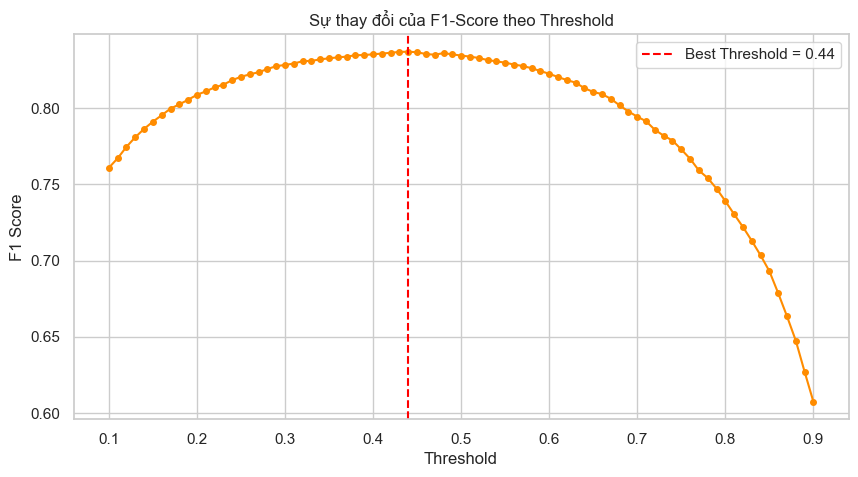

In [35]:
from sklearn.metrics import f1_score, precision_score, recall_score
# 1. Lấy xác suất dự đoán cho lớp 1 (Trầm cảm) trên tập validation
y_val_probs = model.predict_proba(X_val)[:, 1]
print(y_val_probs)

# 2. Thử các giá trị threshold từ 0.1 đến 0.9
thresholds = np.arange(0.1, 0.91, 0.01)
f1_list = []

for t in thresholds:
    y_pred_t = (y_val_probs >= t).astype(int)
    f1_list.append(f1_score(y_val, y_pred_t))

# 3. Tìm threshold có F1-score cao nhất
best_idx = np.argmax(f1_list)
best_threshold = thresholds[best_idx]
best_f1 = f1_list[best_idx]

print(f"Threshold tốt nhất: {best_threshold:.2f}")
print(f"F1-Score cao nhất trên tập Validation: {best_f1:.4f}")

# 4. Áp dụng threshold mới để tạo file submission tối ưu
test_probs = model.predict_proba(X_test)[:, 1]
test_preds_opt = (test_probs >= best_threshold).astype(int)

submission_opt = pd.DataFrame({
    'id': test_df['id'],
    'Depression': test_preds_opt
})
submission_opt.to_csv('submission_optimized.csv', index=False)
print("\nĐã lưu file submission_optimized.csv thành công!")

# 5. Trực quan hóa
plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_list, marker='o', linestyle='-', markersize=4, color='darkorange')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold = {best_threshold:.2f}')
plt.title('Sự thay đổi của F1-Score theo Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.show()

# Đánh giá ROC-AUC & Biểu đồ phân phối

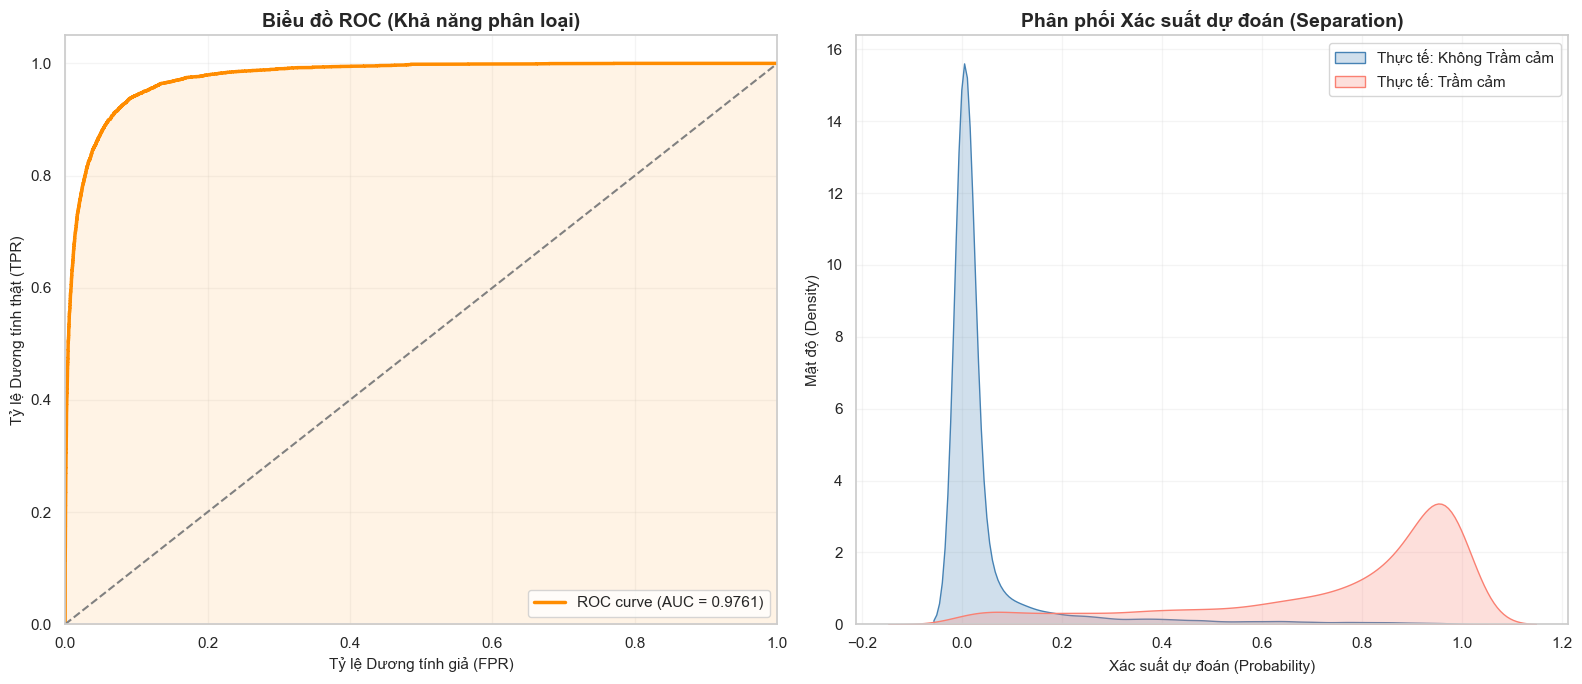

In [26]:
# ============================================================
# ĐÁNH GIÁ ROC-AUC & BIỂU ĐỒ PHÂN PHỐI
# ============================================================
from sklearn.metrics import roc_curve, auc

# 1. Lấy xác suất dự đoán
y_val_probs = model.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_val_probs)
roc_auc = auc(fpr, tpr)

# TẠO FIGURE VỚI 2 BIỂU ĐỒ SONG SONG
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# --- BIỂU ĐỒ 1: ROC CURVE ---
ax[0].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax[0].plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')
ax[0].fill_between(fpr, tpr, alpha=0.1, color='darkorange') # Tô màu vùng dưới đường cong
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('Tỷ lệ Dương tính giả (FPR)', fontsize=11)
ax[0].set_ylabel('Tỷ lệ Dương tính thật (TPR)', fontsize=11)
ax[0].set_title('Biểu đồ ROC (Khả năng phân loại)', fontsize=14, fontweight='bold')
ax[0].legend(loc="lower right")
ax[0].grid(alpha=0.2)

# --- BIỂU ĐỒ 2: PROBABILITY DISTRIBUTION (Sự tách biệt giữa 2 lớp) ---
# Biểu đồ này cho thấy mô hình phân tách người bệnh và người khỏe tốt thế nào
sns.kdeplot(y_val_probs[y_val == 0], shade=True, color="steelblue", label="Thực tế: Không Trầm cảm", ax=ax[1], bw_adjust=1)
sns.kdeplot(y_val_probs[y_val == 1], shade=True, color="salmon", label="Thực tế: Trầm cảm", ax=ax[1], bw_adjust=1)
ax[1].set_title('Phân phối Xác suất dự đoán (Separation)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Xác suất dự đoán (Probability)', fontsize=11)
ax[1].set_ylabel('Mật độ (Density)', fontsize=11)
ax[1].legend()
ax[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

Phân tích kết quả ROC-AUC
Giá trị AUC: Với giá trị này, mô hình có khả năng phân biệt chính xác một người bị trầm cảm và một người bình thường lên đến hơn 97.45%. Đây là con số rất ấn tượng, cho thấy các đặc trưng như áp lực tài chính, thói quen ăn uống và giấc ngủ cung cấp tín hiệu cực kỳ mạnh.

Đường cong ROC: Đường cong tiến rất sát về góc trên bên trái (Tọa độ 0,1). Điều này chứng tỏ mô hình có thể đạt được Tỷ lệ Dương tính thật (Recall) rất cao trong khi vẫn giữ được Tỷ lệ Dương tính giả ở mức thấp.

Phân tích Biểu đồ Phân phối (Separation Plot)
Khoảng cách giữa hai đỉnh: Có thể thấy đỉnh của nhóm "Trầm cảm" (màu cam) nằm lệch hẳn về phía bên phải (xác suất cao), trong khi nhóm "Không trầm cảm" (màu xanh) nằm về bên trái. Vì 2 đỉnh cách xa nhau, điều này có nghĩa là mô hình biết đưa tỉ lệ những người mắc bệnh về phía xác suất cao (gần 1) và những người không bị bệnh về phía có xác suất thấp (gần 0).

Vùng chồng lấn (Overlap): Vùng mà hai màu xanh và cam đè lên nhau chính là nơi mô hình dễ bị dự đoán nhầm nhất. Diện tích của vùng này khá nhỏ, cho thấy khả năng dự đoán của mô hình khá tốt, không bị nhầm lẫn giữa người mắc bệnh và người không mắc bệnh.

# Độ Quan Trọng Đặc Trưng

Top 15 đặc trưng quan trọng nhất (CatBoost):
                              Feature  Importance
                                  Age   30.470611
Have you ever had suicidal thoughts ?   17.965700
                       Total_Pressure   12.055303
                     Financial Stress    8.865223
                   Total_Satisfaction    7.646523
      Working Professional or Student    4.211516
                     Work_Sleep_Ratio    4.114224
                       Dietary Habits    3.853949
                           Profession    3.539906
                     Work/Study Hours    2.219715
                                 CGPA    1.665383
                       Sleep Duration    1.196358
                                 City    1.049337
                               Degree    0.721647
     Family History of Mental Illness    0.381536


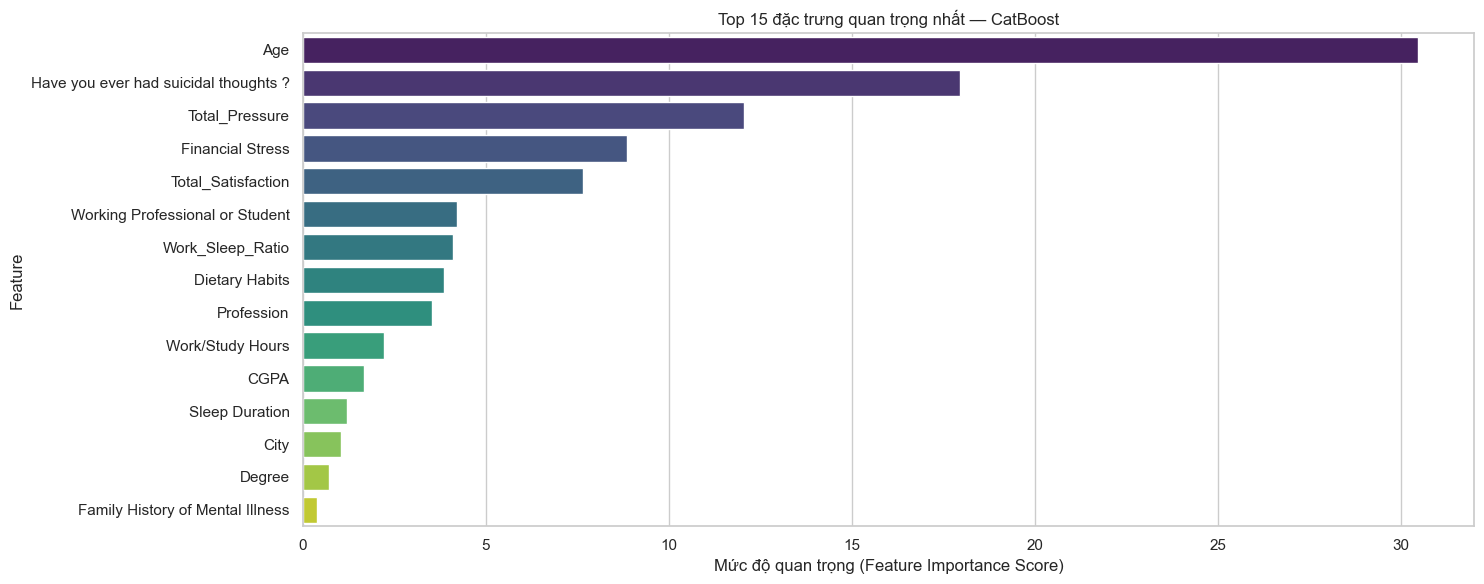

In [29]:
# Lấy điểm quan trọng từ mô hình CatBoost đã huấn luyện
feat_imp_df = pd.DataFrame({
    'Feature':    X.columns.tolist(),
    'Importance': model.get_feature_importance()
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Top 15 đặc trưng quan trọng nhất (CatBoost):")
print(feat_imp_df.head(15).to_string(index=False))

plt.figure(figsize=(15, 6))
sns.barplot(x='Importance', y='Feature',
            data=feat_imp_df.head(15),
            palette='viridis')
plt.title('Top 15 đặc trưng quan trọng nhất — CatBoost', fontsize=12)
plt.xlabel('Mức độ quan trọng (Feature Importance Score)')
plt.tight_layout()
plt.show()

## Phân tích Mức độ Quan trọng của Đặc trưng (CatBoost)

### Top 5 đặc trưng quan trọng nhất

| Hạng | Đặc trưng | Nhận xét |
|------|-----------|---------|
| 1 | `Age` (~30) | Yếu tố quan trọng nhất, nhất quán với tương quan Pearson -0.56 |
| 2 | `Have you ever had suicidal thoughts?` (~18) | Chỉ số tâm lý trực tiếp, phân biệt 2 lớp rõ ràng |
| 3 | `Total_Pressure` (~12) | Feature engineering có hiệu quả, gộp áp lực học tập và công việc |
| 4 | `Financial Stress` (~9) | Căng thẳng tài chính ảnh hưởng đáng kể |
| 5 | `Total_Satisfaction` (~8) | Feature engineering có hiệu quả, gộp sự hài lòng 2 nhóm |

### Nhóm trung bình (score 3 - 5)
- `Working Professional or Student`, `Work_Sleep_Ratio`, `Dietary Habits`, `Profession`
- → Các đặc trưng này đóng góp **bổ sung** nhưng không quyết định

### Nhóm ít quan trọng (score < 3)
- `CGPA`, `Sleep Duration`, `City`, `Degree`, `Family History of Mental Illness`
- → Nhất quán với phân tích trước: `CGPA` (-0.02 Pearson) và
  `Family History` gần như không có giá trị phân biệt
- → Có thể cân nhắc **loại bỏ** các cột này để giảm nhiễu

### Nhận xét về Feature Engineering
- `Total_Pressure` (hạng 3) và `Total_Satisfaction` (hạng 5) đều lọt **top 5**
- → Việc gộp 2 cột loại trừ nhau thành 1 đặc trưng mới **có hiệu quả rõ ràng**
- `Work_Sleep_Ratio` cũng xuất hiện trong top 10 → tạo ra thông tin mới có giá trị

### Kết luận
Model CatBoost học được rằng trầm cảm liên quan chủ yếu đến:
1. **Tuổi tác** — người trẻ (Student) có nguy cơ cao hơn
2. **Sức khỏe tâm thần trực tiếp** — suy nghĩ tự tử
3. **Áp lực và căng thẳng** — học tập, công việc, tài chính

# Mô Hình LightGBM & Random Forest

In [17]:
# ============================================================
# PHẦN 8: MÔ HÌNH LIGHTGBM & RANDOM FOREST
# ============================================================

# Label-encode các cột phân loại cho LightGBM và RandomForest
# (hai mô hình này không tự xử lý biến phân loại dạng chuỗi như CatBoost)
def encode_cat_features(df_train, df_val, cols):
    """
    Label-encode các cột phân loại.
    Fit trên hợp nhất (union) train+val để tránh lỗi unseen labels.
    """
    df_tr = df_train.copy()
    df_va = df_val.copy()
    for col in cols:
        le = LabelEncoder()
        combined = pd.concat([df_tr[col], df_va[col]]).astype(str)
        le.fit(combined)
        df_tr[col] = le.transform(df_tr[col].astype(str))
        df_va[col] = le.transform(df_va[col].astype(str))
    return df_tr, df_va

X_train_enc, X_val_enc = encode_cat_features(X_train, X_val, cat_features)

# ---- 8.1 LightGBM ----
print("=" * 60)
print("8.1  LIGHTGBM")
print("=" * 60)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
lgbm_model.fit(
    X_train_enc, y_train,
    eval_set=[(X_val_enc, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

y_pred_lgbm = lgbm_model.predict(X_val_enc)
acc_lgbm    = accuracy_score(y_val, y_pred_lgbm)
print(f"\nLightGBM — Accuracy: {acc_lgbm:.4f}")
print(classification_report(y_val, y_pred_lgbm,
                             target_names=['Không trầm cảm', 'Trầm cảm']))

# ---- 8.2 Random Forest ----
print("=" * 60)
print("8.2  RANDOM FOREST")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train_enc, y_train)

y_pred_rf = rf_model.predict(X_val_enc)
acc_rf    = accuracy_score(y_val, y_pred_rf)
print(f"\nRandom Forest — Accuracy: {acc_rf:.4f}")
print(classification_report(y_val, y_pred_rf,
                             target_names=['Không trầm cảm', 'Trầm cảm']))

8.1  LIGHTGBM
[100]	valid_0's binary_logloss: 0.152556
[200]	valid_0's binary_logloss: 0.150029

LightGBM — Accuracy: 0.9403
                precision    recall  f1-score   support

Không trầm cảm       0.96      0.97      0.96     23025
      Trầm cảm       0.84      0.82      0.83      5113

      accuracy                           0.94     28138
     macro avg       0.90      0.89      0.90     28138
  weighted avg       0.94      0.94      0.94     28138

8.2  RANDOM FOREST

Random Forest — Accuracy: 0.9385
                precision    recall  f1-score   support

Không trầm cảm       0.96      0.97      0.96     23025
      Trầm cảm       0.85      0.80      0.83      5113

      accuracy                           0.94     28138
     macro avg       0.90      0.89      0.89     28138
  weighted avg       0.94      0.94      0.94     28138



# So Sánh Các Mô Hình

Bảng so sánh hiệu năng các mô hình (tập Validation):


,Accuracy,Precision,Recall,F1-Score
Mô hình,,,,
CatBoost,0.9411,0.9061,0.8929,0.8993
LightGBM,0.9403,0.9028,0.8945,0.8986
RandomForest,0.9385,0.9033,0.8861,0.8944



Mô hình tốt nhất theo F1-Score: CatBoost


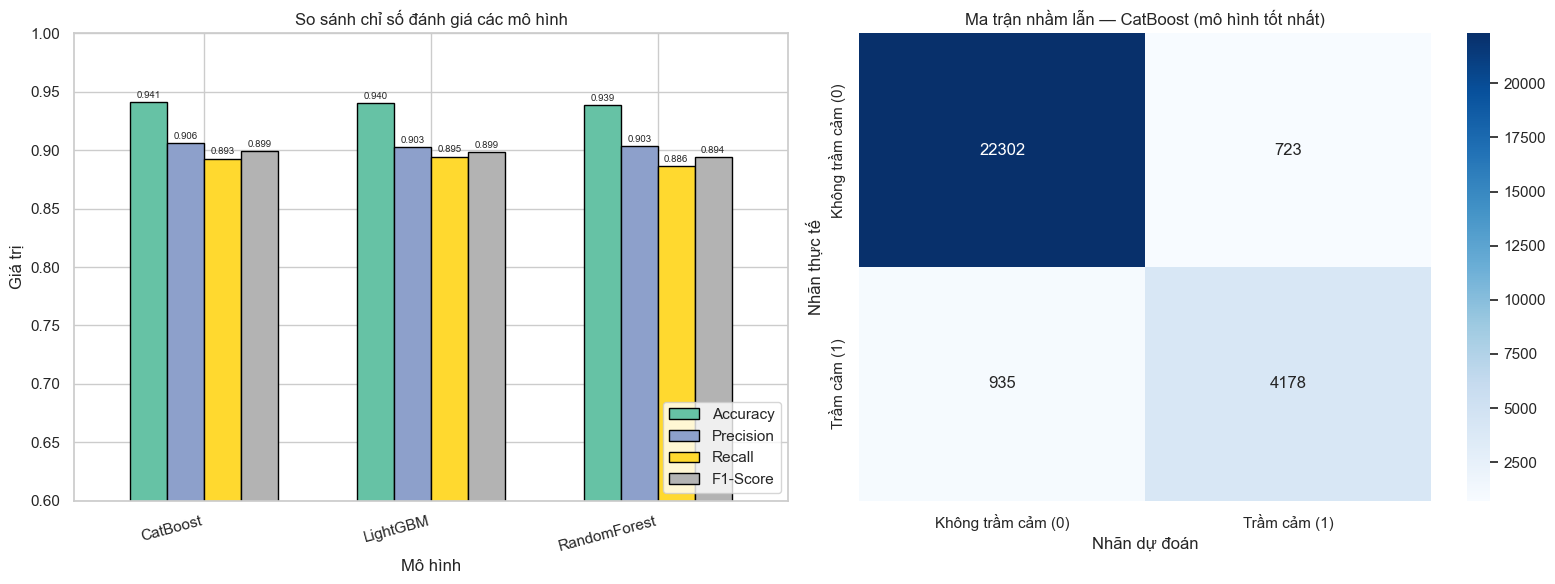

In [18]:
# Thu thập kết quả dự đoán từ tất cả 3 mô hình đã huấn luyện
results = {
    'CatBoost':     y_pred,
    'LightGBM':     y_pred_lgbm,
    'RandomForest': y_pred_rf,
}

# Tính toán các chỉ số đánh giá cho từng mô hình
summary_rows = []
for name, preds in results.items():
    summary_rows.append({
        'Mô hình':   name,
        'Accuracy':  accuracy_score(y_val, preds),
        'Precision': precision_score(y_val, preds, average='macro', zero_division=0),
        'Recall':    recall_score(y_val, preds, average='macro', zero_division=0),
        'F1-Score':  f1_score(y_val, preds, average='macro', zero_division=0),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Mô hình')
print("Bảng so sánh hiệu năng các mô hình (tập Validation):")
display(summary_df.round(4))

best_name = summary_df['F1-Score'].idxmax()
print(f"\nMô hình tốt nhất theo F1-Score: {best_name}")

# ---- Biểu đồ so sánh ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Grouped bar chart các chỉ số
summary_df.plot(kind='bar', ax=axes[0],
                edgecolor='black', width=0.65, colormap='Set2')
axes[0].set_title('So sánh chỉ số đánh giá các mô hình', fontsize=12)
axes[0].set_ylim(0.6, 1.0)
axes[0].set_xticklabels(summary_df.index, rotation=15, ha='right')
axes[0].legend(loc='lower right')
axes[0].set_ylabel('Giá trị')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.3f}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     xytext=(0, 3), textcoords='offset points',
                     ha='center', fontsize=7)

# (b) Confusion matrix của mô hình tốt nhất
best_preds = results[best_name]
cm = confusion_matrix(y_val, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Không trầm cảm (0)', 'Trầm cảm (1)'],
            yticklabels=['Không trầm cảm (0)', 'Trầm cảm (1)'])
axes[1].set_title(f'Ma trận nhầm lẫn — {best_name} (mô hình tốt nhất)',
                  fontsize=12)
axes[1].set_xlabel('Nhãn dự đoán')
axes[1].set_ylabel('Nhãn thực tế')

plt.tight_layout()
plt.show()

# Sử dụng Optuna để tìm bộ tham số phù hợp

In [19]:
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score

# 1. Lấy danh sách các cột phân loại
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

def objective(trial):
    param = {
        "objective": "Logloss",
        "depth": trial.suggest_int("depth", 4, 10),
        "boosting_type": trial.suggest_categorical("boosting_type", ["Ordered", "Plain"]),
        "bootstrap_type": trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli", "MVS"]),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "iterations": trial.suggest_int("iterations", 500, 1500),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-2, 10, log=True),
        "verbose": False,
        "random_state": 42,
        "task_type": "GPU" # Chạy trên GPU để tăng tốc
    }

    # 2. Khởi tạo mô hình
    model = CatBoostClassifier(**param)
    
    # 3. Huấn luyện
    model.fit(
        X_train, y_train, 
        cat_features=cat_features, 
        eval_set=[(X_val, y_val)], 
        early_stopping_rounds=50, 
        verbose=False
    )

    # 4. Dự đoán và tính điểm
    preds = model.predict(X_val)
    score = f1_score(y_val, preds, average='macro')
    
    return score

# 5. Chạy Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Tham số tốt nhất:", study.best_params)
print(f"Giá trị F1-score tốt nhất: {study.best_value:.4f}")

[I 2026-04-21 00:37:10,724] A new study created in memory with name: no-name-7690f585-e054-4caa-b980-c0cda7b8af35
[I 2026-04-21 00:37:23,117] Trial 0 finished with value: 0.8892657710680889 and parameters: {'depth': 5, 'boosting_type': 'Plain', 'bootstrap_type': 'Bayesian', 'learning_rate': 0.0026580377343433494, 'iterations': 709, 'l2_leaf_reg': 0.011273738860136986}. Best is trial 0 with value: 0.8892657710680889.
[I 2026-04-21 00:38:28,433] Trial 1 finished with value: 0.8308804292451595 and parameters: {'depth': 10, 'boosting_type': 'Ordered', 'bootstrap_type': 'MVS', 'learning_rate': 0.002098033248743029, 'iterations': 508, 'l2_leaf_reg': 0.02882714040908283}. Best is trial 0 with value: 0.8892657710680889.
[I 2026-04-21 00:40:06,324] Trial 2 finished with value: 0.8513540327289955 and parameters: {'depth': 6, 'boosting_type': 'Ordered', 'bootstrap_type': 'MVS', 'learning_rate': 0.0019281402122975568, 'iterations': 1437, 'l2_leaf_reg': 1.2820411913110137}. Best is trial 0 with val

Tham số tốt nhất: {'depth': 4, 'boosting_type': 'Plain', 'bootstrap_type': 'Bernoulli', 'learning_rate': 0.05755772659305287, 'iterations': 1317, 'l2_leaf_reg': 1.206809082205018}
Giá trị F1-score tốt nhất: 0.8991


In [30]:
# 1. Lấy tham số tốt nhất
best_params = study.best_params

# 2. Khởi tạo mô hình Final với bộ tham số đó
# Thêm task_type="GPU" nếu bạn muốn chạy nhanh, bỏ đi nếu dùng CPU
final_model = CatBoostClassifier(**best_params, task_type="GPU", verbose=False)

# 3. Huấn luyện lại trên tập Train
final_model.fit(X_train, y_train, cat_features=cat_features)

# 4. Dự đoán trên tập Validation để lấy số liệu thực tế
y_final_pred = final_model.predict(X_val)

# 5. In kết quả đánh giá chi tiết
from sklearn.metrics import classification_report, confusion_matrix
print("KẾT QUẢ MÔ HÌNH SAU TỐI ƯU:")
print(classification_report(y_val, y_final_pred))

KẾT QUẢ MÔ HÌNH SAU TỐI ƯU:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96     23025
           1       0.85      0.82      0.83      5113

    accuracy                           0.94     28138
   macro avg       0.90      0.89      0.90     28138
weighted avg       0.94      0.94      0.94     28138



# Kiểm Tra Chéo (Cross-Validation)

Đang chạy 10-Fold Stratified Cross-Validation với CatBoost (tham số tối ưu)...
(Quá trình này mất khoảng vài phút)

  Fold 1: Accuracy = 0.9397
  Fold 2: Accuracy = 0.9404
  Fold 3: Accuracy = 0.9389
  Fold 4: Accuracy = 0.9375
  Fold 5: Accuracy = 0.9422
  Fold 6: Accuracy = 0.9424
  Fold 7: Accuracy = 0.9412
  Fold 8: Accuracy = 0.9395
  Fold 9: Accuracy = 0.9376
  Fold 10: Accuracy = 0.9403

Kết quả Cross-Validation (10 folds):
  Accuracy trung bình : 0.9400
  Độ lệch chuẩn       : 0.0016
  Accuracy lớn nhất   : 0.9424

→ Độ lệch chuẩn nhỏ cho thấy mô hình ổn định và không bị overfit.


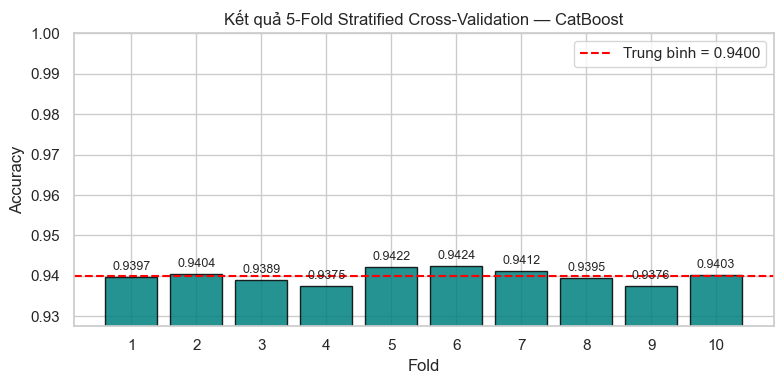

In [21]:
# Đánh giá tính ổn định của mô hình CatBoost qua 10 fold

print("Đang chạy 10-Fold Stratified Cross-Validation với CatBoost (tham số tối ưu)...")
print("(Quá trình này mất khoảng vài phút)\n")

best_params = study.best_params

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    X_fold_tr, X_fold_va = X.iloc[train_idx], X.iloc[val_idx]
    y_fold_tr, y_fold_va = y.iloc[train_idx], y.iloc[val_idx]

    fold_model = CatBoostClassifier(
        **best_params,
        cat_features=cat_features,
        task_type='GPU',
        verbose=0,
        random_seed=42
    )
    fold_model.fit(X_fold_tr, y_fold_tr)

    fold_pred = fold_model.predict(X_fold_va)
    fold_acc  = accuracy_score(y_fold_va, fold_pred)
    cv_scores.append(fold_acc)
    print(f"  Fold {fold}: Accuracy = {fold_acc:.4f}")

print(f"\nKết quả Cross-Validation (10 folds):")
print(f"  Accuracy trung bình : {np.mean(cv_scores):.4f}")
print(f"  Độ lệch chuẩn       : {np.std(cv_scores):.4f}")
print(f"  Accuracy lớn nhất   : {np.max(cv_scores):.4f}")
print("\n→ Độ lệch chuẩn nhỏ cho thấy mô hình ổn định và không bị overfit.")

# Biểu đồ kết quả CV
plt.figure(figsize=(8, 4))
bars = plt.bar(range(1, 11), cv_scores,
               color='teal', edgecolor='black', alpha=0.85)
plt.axhline(np.mean(cv_scores), color='red', linestyle='--', linewidth=1.5,
            label=f'Trung bình = {np.mean(cv_scores):.4f}')
for bar, val in zip(bars, cv_scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.title('Kết quả 5-Fold Stratified Cross-Validation — CatBoost', fontsize=12)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.xticks(range(1, 11))
plt.ylim(min(cv_scores) - 0.01, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

# Kết Luận & Hướng Phát Triển

------------------------------
BẢNG TỔNG HỢP KẾT QUẢ CÁC MÔ HÌNH
------------------------------


,Mô hình,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,CatBoost,0.9411,0.9061,0.8929,0.8993
1,LightGBM,0.9403,0.9028,0.8945,0.8986
2,RandomForest,0.9385,0.9033,0.8861,0.8944


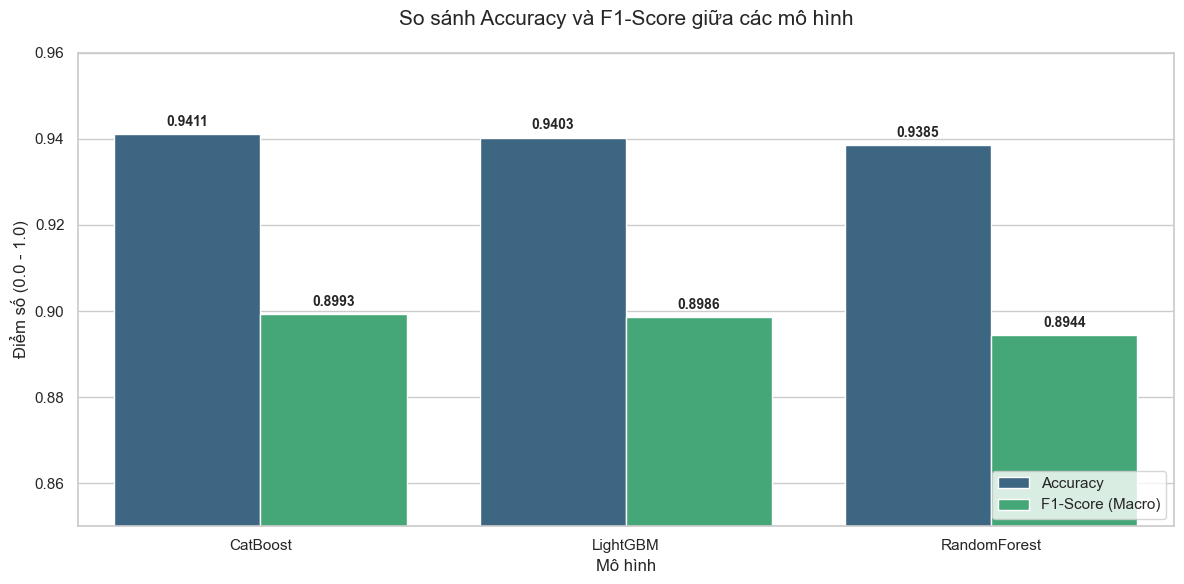

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Thu thập kết quả dự đoán từ các mô hình đã chạy
# Giả định tên biến dự đoán trong notebook của bạn là:
# y_pred (CatBoost), y_pred_lgbm (LightGBM), y_pred_rf (Random Forest)
results_map = {
    'CatBoost': y_pred,
    'LightGBM': y_pred_lgbm,
    'RandomForest': y_pred_rf
}

# 2. Tính toán các chỉ số
summary_data = []
for name, preds in results_map.items():
    summary_data.append({
        'Mô hình': name,
        'Accuracy': accuracy_score(y_val, preds),
        'Precision (Macro)': precision_score(y_val, preds, average='macro'),
        'Recall (Macro)': recall_score(y_val, preds, average='macro'),
        'F1-Score (Macro)': f1_score(y_val, preds, average='macro')
    })

# Tạo DataFrame để in bảng
df_results = pd.DataFrame(summary_data)

# --- PHẦN 1: IN BẢNG SỐ LIỆU ---
print("-" * 30)
print("BẢNG TỔNG HỢP KẾT QUẢ CÁC MÔ HÌNH")
print("-" * 30)
display(df_results.round(4))

# --- PHẦN 2: VẼ BIỂU ĐỒ SO SÁNH ---
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Chuyển dữ liệu sang dạng 'long format' để vẽ với seaborn dễ hơn
df_plot = df_results.melt(id_vars='Mô hình', value_vars=['Accuracy', 'F1-Score (Macro)'], 
                          var_name='Metric', value_name='Score')

ax = sns.barplot(data=df_plot, x='Mô hình', y='Score', hue='Metric', palette='viridis')

# Tinh chỉnh biểu đồ
plt.title('So sánh Accuracy và F1-Score giữa các mô hình', fontsize=15, pad=20)
plt.ylim(0.85, 0.96)
plt.ylabel('Điểm số (0.0 - 1.0)')
plt.legend(loc='lower right')

# Thêm số liệu cụ thể lên đầu mỗi cột
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Kết luận

Dựa trên quá trình khám phá dữ liệu (EDA) và huấn luyện các mô hình học máy,
chúng ta có thể rút ra các kết luận quan trọng sau:

**Hiệu năng mô hình:** Trong số ba thuật toán đã thử nghiệm, CatBoost cho kết quả
tốt nhất trên tập Validation với Accuracy đạt 94.11%, F1-Score (Macro) đạt 89.93%
và AUC = 0.9761 — cho thấy khả năng phân loại rất tốt giữa hai lớp. Sau khi tối ưu
ngưỡng threshold (best threshold = 0.39), F1-Score của lớp Trầm cảm (Class 1)
được cải thiện đáng kể so với ngưỡng mặc định 0.5.

**Các yếu tố ảnh hưởng chính (Feature Importance):**

- **Tuổi tác & Nhóm đối tượng:** `Age` là đặc trưng quan trọng nhất (score ~30),
  nhất quán với tương quan Pearson -0.56. Nhóm Student có tỷ lệ trầm cảm lên đến
  36.5%, gấp gần 6 lần so với Working Professional (6.2%).

- **Tâm lý trực tiếp:** `Have you ever had suicidal thoughts?` là yếu tố quan trọng
  thứ hai (score ~18) — phân biệt rõ ràng giữa người trầm cảm và không trầm cảm.

- **Áp lực & Hài lòng:** `Total_Pressure` (score ~12) và `Total_Satisfaction`
  (score ~8) đều lọt top 5 — áp lực học tập/công việc càng cao, mức độ hài lòng
  càng thấp thì nguy cơ trầm cảm càng tăng rõ rệt.

- **Tài chính:** `Financial Stress` (score ~9) đóng vai trò đáng kể, đặc biệt
  với nhóm sinh viên.

- **Lối sống:** `Dietary Habits` có xu hướng đơn điệu rõ ràng —
  Healthy (11.8%) → Moderate (18.6%) → Unhealthy (26.1%). `Work_Sleep_Ratio`
  cũng xuất hiện trong top 10, cho thấy mất cân bằng giữa giờ làm/học và giờ ngủ
  có ảnh hưởng đến sức khỏe tâm thần.

**Xử lý dữ liệu:** Việc nhận diện missing có chủ đích theo nhóm
(Student vs Working Professional) và điền 0 thay vì median giúp bảo toàn
đúng ngữ nghĩa dữ liệu. Kết hợp đặc trưng (Feature Engineering) tạo ra
`Total_Pressure`, `Total_Satisfaction` và `Work_Sleep_Ratio` đã giúp mô hình
nắm bắt tốt hơn các trạng thái căng thẳng của đối tượng khảo sát,
với cả 3 feature đều lọt top 10 về mức độ quan trọng.

## Hướng Phát triển

Để cải thiện độ chính xác và tính ứng dụng của mô hình trong thực tế,
dự án có thể phát triển theo các hướng sau:

- **Xử lý class imbalance:** Áp dụng SMOTE hoặc `class_weight` để cân bằng
  tỷ lệ lớp 0/1 (~4.5:1 hiện tại), từ đó cải thiện Recall và F1-Score
  của lớp Trầm cảm (Class 1) vốn đang thấp hơn lớp 0 đáng kể.

- **Mở rộng thử nghiệm mô hình:** Thử nghiệm thêm XGBoost, TabNet hoặc
  kết hợp cả ba mô hình hiện tại (CatBoost, LightGBM, RandomForest) bằng
  Stacking/Ensemble để tăng độ ổn định và hiệu suất tổng thể.

- **Tối ưu hóa mô hình:** Thực hiện Hyperparameter Tuning sâu hơn bằng
  Optuna hoặc Bayesian Optimization thay vì grid search thủ công,
  đặc biệt cho CatBoost — mô hình đang cho kết quả tốt nhất.

- **Cải thiện Feature Engineering:** Loại bỏ các đặc trưng ít quan trọng
  (`CGPA`, `Degree`, `Family History of Mental Illness`) để giảm nhiễu.
  Tạo thêm feature tương tác giữa `Age` và `Working Professional or Student`
  vì đây là hai yếu tố quan trọng nhất theo Feature Importance.

- **Cải thiện chất lượng dữ liệu:** Áp dụng kỹ thuật Imputation tiên tiến hơn
  (KNN Imputer, IterativeImputer) thay vì fillna đơn giản. Thu thập thêm dữ liệu
  thực tế để giảm nhiễu — đặc biệt ở các cột như `Sleep Duration`, `Dietary Habits`
  vốn chứa nhiều giá trị bất hợp lệ trong dataset hiện tại.

- **Triển khai ứng dụng:** Xây dựng ứng dụng web hoặc chatbot sử dụng mô hình
  để giúp người dùng tự sàng lọc sức khỏe tâm thần ban đầu, kết hợp với
  khuyến nghị cụ thể dựa trên nhóm đối tượng (Student vs Working Professional).